# LazySlide + StainX stain normalization

This tutorial shows how to normalize H&E tile colors with
[StainX](https://stainx.readthedocs.io/) inside a [LazySlide](https://lazyslide.readthedocs.io/) workflow.

You will:

1. Preprocess a sample WSI (tissues → tiles)
2. Fit a Macenko normalizer once on StainX's public `target.png` reference
3. Compare original vs normalized tiles
4. Pass a composed transform into `zs.tl.feature_extraction`


## Install

Requires Python ≥ 3.11.

In [1]:
%pip install -q "lazyslide" "stainx" "matplotlib" "torchvision"

Note: you may need to restart the kernel to use updated packages.


## 1. Preprocess a WSI

Same entry points as the LazySlide preprocessing tutorial: sample slide → tissues → tiles.

In [2]:
%matplotlib inline

import lazyslide as zs
import torch
import matplotlib.pyplot as plt
from torchvision.transforms import v2 as transforms

from stainx import StainNormalizerTransform

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

wsi = zs.datasets.sample()  # small CMU-1 region from LazySlide HF data
zs.pp.find_tissues(wsi)
zs.pp.tile_tissues(wsi, tile_px=256, mpp=0.5)
print("n_tiles:", len(wsi["tiles"]))


device: cuda


n_tiles: 31


## 2. Load a few tiles as Torch tensors

`WSIData` exposes a tile image dataset. Batches use an `"image"` key.
Raw tiles are typically uint8 HWC NumPy arrays; StainX expects float NCHW in `[0, 1]`.

In [3]:
ds = wsi.ds.tile_images(tile_key="tiles", transform=None)


def to_nchw_float01(img) -> torch.Tensor:
    """Normalize dataset output to float NCHW in [0, 1]."""
    if not isinstance(img, torch.Tensor):
        img = transforms.functional.to_image(img)
        img = transforms.functional.to_dtype(img, torch.float32, scale=True)
    if img.dim() == 3 and img.shape[-1] == 3:  # HWC
        img = img.permute(2, 0, 1)
    if img.dim() == 3:
        img = img.unsqueeze(0)
    if img.dtype == torch.uint8:
        img = img.float() / 255.0
    elif img.dtype.is_floating_point and float(img.amax()) > 1.5:
        img = img / 255.0
    return img


n_show = min(4, len(ds))
tiles = torch.cat([to_nchw_float01(ds[i]["image"]) for i in range(n_show)], dim=0)
print("tiles", tuple(tiles.shape), tiles.dtype, float(tiles.amin()), float(tiles.amax()))

tiles (4, 3, 256, 256) torch.float32 0.0 1.0


## 3. Fit StainX once on a fixed reference

Use the same reference tile as the StainX examples:
[`examples/data/target.png`](https://github.com/rendeirolab/stainx/blob/main/examples/data/target.png)
(downloaded from GitHub). Prefer a fixed cohort reference like this in production
rather than fitting on a tile from the slide under analysis.

`StainNormalizerTransform` with `normalize_to_0_1=True` (default for Macenko) keeps
outputs in `[0, 1]` for downstream models.


In [4]:
from io import BytesIO
from urllib.request import urlopen

from PIL import Image

_RAW = "https://raw.githubusercontent.com/rendeirolab/stainx/main/examples/data"


def fetch_reference(name: str = "target.png", size: int = 256) -> torch.Tensor:
    """Download StainX example RGB tile → float NCHW [0, 1]."""
    with urlopen(f"{_RAW}/{name}") as resp:
        img = Image.open(BytesIO(resp.read())).convert("RGB")
    img = img.resize((size, size), Image.Resampling.BILINEAR)
    t = transforms.functional.to_image(img)
    t = transforms.functional.to_dtype(t, torch.float32, scale=True)  # (3, H, W)
    return t.unsqueeze(0)  # (1, 3, H, W)


reference = fetch_reference().to(device)
print("reference", tuple(reference.shape), _RAW + "/target.png")

stain_tf = StainNormalizerTransform(
    method="macenko",
    mode="reference",
    reference=reference,
    device=device,
)

normalized = stain_tf(tiles.to(device)).cpu()
print(
    "normalized",
    tuple(normalized.shape),
    float(normalized.amin()),
    float(normalized.amax()),
)


reference (1, 3, 256, 256) https://raw.githubusercontent.com/rendeirolab/stainx/main/examples/data/target.png


normalized (4, 3, 256, 256) 0.0006183742079883814 1.0


## 4. Visualize before / after

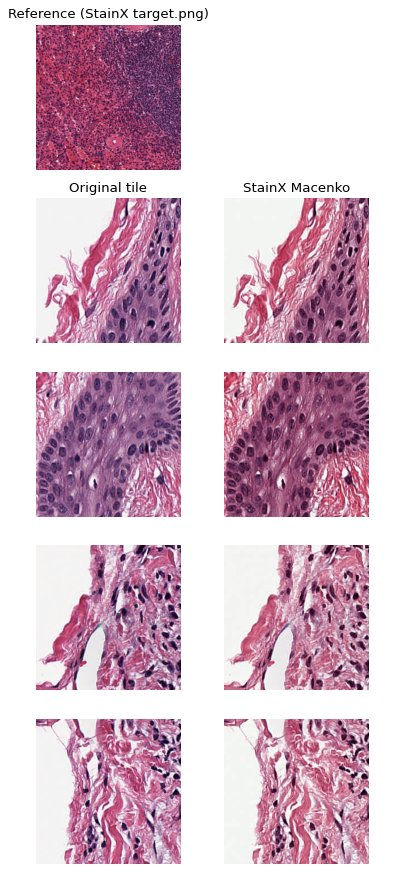

In [5]:
import io
from IPython.display import Image as IPyImage, display


def show_grid(raw: torch.Tensor, normed: torch.Tensor, ref: torch.Tensor, max_n: int = 4):
    n = min(max_n, raw.shape[0])
    # Reference on top, then original | normalized rows
    fig, axes = plt.subplots(n + 1, 2, figsize=(5, 2.2 * (n + 1)), facecolor="white", dpi=80)
    axes[0, 0].imshow(ref[0].detach().cpu().permute(1, 2, 0).clamp(0, 1).numpy())
    axes[0, 0].set_title("Reference (StainX target.png)")
    axes[0, 0].axis("off")
    axes[0, 1].axis("off")
    for i in range(n):
        for ax, t, title in zip(
            axes[i + 1],
            (raw[i], normed[i]),
            ("Original tile", "StainX Macenko"),
            strict=True,
        ):
            ax.imshow(t.detach().permute(1, 2, 0).clamp(0, 1).numpy())
            ax.set_title(title if i == 0 else "")
            ax.axis("off")
    fig.tight_layout()
    buf = io.BytesIO()
    fig.savefig(buf, format="jpeg", dpi=80, bbox_inches="tight", pil_kwargs={"quality": 85})
    plt.close(fig)
    display(IPyImage(data=buf.getvalue(), format="jpeg"))


show_grid(tiles, normalized, reference)


## 5. Plug into `feature_extraction` via `transform=`

Compose **StainX → model transform**. StainX expects float NCHW `[0, 1]`;
foundation-model transforms usually start from uint8 / PIL and apply ImageNet normalization.

Fit the stain transform once, then pass the composed callable to
`zs.tl.feature_extraction(..., transform=...)`.

In [6]:
from lazyslide_models import TimmModel
from torchvision.transforms import v2 as T


class StainXThenModel:
    """Apply StainX (NCHW float [0,1]) then the model's default transform."""

    def __init__(self, stain: StainNormalizerTransform, model_transform):
        self.stain = stain
        self.model_transform = model_transform

    def __call__(self, img):
        x = to_nchw_float01(img)  # (1, 3, H, W)
        x = self.stain(x)[0]  # (3, H, W) float [0, 1]
        u8 = (x.clamp(0, 1) * 255).round().to(torch.uint8)
        return self.model_transform(T.functional.to_pil_image(u8))


model_tf = TimmModel("resnet50").get_transform()
composed = StainXThenModel(stain_tf, model_tf)

zs.tl.feature_extraction(
    wsi,
    model="resnet50",
    transform=composed,
    device=device,
    batch_size=8,
    key_added="resnet50_stainx_tiles",
)
print("features:", "resnet50_stainx_tiles" in wsi.tables)
print("shape:", wsi.tables["resnet50_stainx_tiles"].X.shape)

features: True
shape: (31, 2048)


## Tips

- This notebook fits on StainX's public `target.png`; for your own work, keep one fixed cohort reference across train/val/test.
- Prefer `mode="reference"` for training; `mode="batch"` re-estimates stains per batch and is usually unsafe for learning.
- StainX also supports Reinhard and histogram matching — see the
  [StainX docs](https://stainx.readthedocs.io/).
- StainX is GPL-3.0-or-later; cite both packages if you publish results.
